# Train a Deep NN to predict Asset Price returns

In practice, we need to explore variations of the design options outlined above because we can rarely be sure from the outset which network architecture best suits the data.

In this section, we will explore various options to build a simple feedforward Neural Network to predict asset price returns for a one-day horizon.

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline

import os, sys
from ast import literal_eval as make_tuple
from time import time
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import spearmanr
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
#sys.path.insert(1, os.path.join(sys.path[0], '..'))
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from utils import MultipleTimeSeriesCV, format_time

In [5]:
np.random.seed(42)
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [6]:
results_path = Path('results')
if not results_path.exists():
    results_path.mkdir()
    
checkpoint_path = results_path / 'logs'

## Create a stock return series to predict asset price moves

In [7]:
DATA_FILE = './data_yf.h5'
#data = pd.read_hdf('./data.h5', 'model_data').dropna().sort_index() 
data = pd.read_hdf(DATA_FILE, 'model_data').dropna().sort_index()

### Filter the top most-traded stocks

In [8]:
print(len(data.index.get_level_values('symbol').unique()))
data = data[data['dollar_vol_rank'] < 300]
print(len(data.index.get_level_values('symbol').unique()))

927
666


In [9]:
dates_tmp = data.index.get_level_values('date').unique()
print(f'dates ranging from {dates_tmp.min()} to {dates_tmp.max()}')


dates ranging from 2009-08-05 00:00:00 to 2025-03-26 00:00:00


In [10]:
data.index.get_level_values('symbol').unique()

Index(['AAL', 'AAOI', 'AAON', 'AAPL', 'ACGL', 'ACHC', 'ACIW', 'ACLS', 'ACMR',
       'ACTG',
       ...
       'XRX', 'Z', 'ZBRA', 'ZD', 'ZEUS', 'ZG', 'ZION', 'ZLAB', 'ZS', 'ZVRA'],
      dtype='object', name='symbol', length=666)

In [11]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1144393 entries, ('AAL', Timestamp('2009-08-05 00:00:00')) to ('ZVRA', Timestamp('2021-03-31 00:00:00'))
Data columns (total 34 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   dollar_vol       1144393 non-null  float64
 1   dollar_vol_rank  1144393 non-null  float64
 2   rsi              1144393 non-null  float64
 3   bb_high          1144393 non-null  float64
 4   bb_low           1144393 non-null  float64
 5   NATR             1144393 non-null  float64
 6   ATR              1144393 non-null  float64
 7   PPO              1144393 non-null  float64
 8   MACD             1144393 non-null  float64
 9   sector           1144393 non-null  int64  
 10  r01              1144393 non-null  float64
 11  r05              1144393 non-null  float64
 12  r10              1144393 non-null  float64
 13  r21              1144393 non-null  float64
 14  r42              1144393 non-null  floa

In [12]:
outcomes = data.filter(like='fwd').columns.tolist()
outcomes

['r01_fwd', 'r05_fwd', 'r21_fwd']

In [13]:
lookahead = 1
outcome= f'r{lookahead:02}_fwd'

In [14]:
END_DATE = '2025'
X_cv = data.loc[idx[:, :END_DATE], :].drop(outcomes, axis=1)
y_cv = data.loc[idx[:, :END_DATE], outcome]

In [15]:
dates_tmp = X_cv.index.get_level_values('date').unique()
print(f'dates ranging from {dates_tmp.min()} to {dates_tmp.max()}')


dates ranging from 2009-08-05 00:00:00 to 2025-03-26 00:00:00


In [16]:
print('number of tickers',len(X_cv.index.get_level_values('symbol').unique()))

number of tickers 666


In [17]:
X_cv.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1144393 entries, ('AAL', Timestamp('2009-08-05 00:00:00')) to ('ZVRA', Timestamp('2021-03-31 00:00:00'))
Data columns (total 31 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   dollar_vol       1144393 non-null  float64
 1   dollar_vol_rank  1144393 non-null  float64
 2   rsi              1144393 non-null  float64
 3   bb_high          1144393 non-null  float64
 4   bb_low           1144393 non-null  float64
 5   NATR             1144393 non-null  float64
 6   ATR              1144393 non-null  float64
 7   PPO              1144393 non-null  float64
 8   MACD             1144393 non-null  float64
 9   sector           1144393 non-null  int64  
 10  r01              1144393 non-null  float64
 11  r05              1144393 non-null  float64
 12  r10              1144393 non-null  float64
 13  r21              1144393 non-null  float64
 14  r42              1144393 non-null  floa

## Automate model generation

The following `make_model` function illustrates how to flexibly define various architectural elements for the search process. The dense_layers argument defines both the depth and width of the network as a list of integers. We also use dropout for regularization, expressed as a float in the range [0, 1] to define the probability that a given unit will be excluded from a training iteration.

In [18]:
def make_model(dense_layers, activation, dropout, input_dim):
    """PyTorch equivalent of TensorFlow's make_model function
    
    Args:
        dense_layers: List/tuple of layer sizes
        activation: Activation function name ('relu', 'tanh', etc.)
        dropout: Dropout rate
        input_dim: Input dimension (number of features)
    
    Returns:
        model: PyTorch model
        criterion: Loss function
        optimizer: Optimizer
    """
    model = MLP(input_dim, dense_layers, activation, dropout)
    criterion = nn.MSELoss()  # mean squared error
    optimizer = optim.Adam(model.parameters())
    
    return model, criterion, optimizer

def train_epoch(model, criterion, optimizer, x_train, y_train, batch_size, shuffle=True):
    """Train for one epoch"""
    model.train()
    
    # Convert numpy arrays to PyTorch tensors
    x_tensor = torch.FloatTensor(x_train)
    y_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
    
    # Create dataset and dataloader
    dataset = TensorDataset(x_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    running_loss = 0.0
    for inputs, targets in dataloader:
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    return running_loss / len(dataset)

def predict(model, x_val):
    """Make predictions"""
    model.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_val)
        predictions = model(x_tensor).numpy()
    return predictions.squeeze()

## Cross-validate multiple configurations with TensorFlow

### Train-Test Split

We split the data into a training set for cross-validation, and keep the last 12 months with data as holdout test:

In [19]:
# Define parameters for CV

#train_period_length=21 * 12 * 4 # train on 4 years
#test_period_length=21 * 3 # test on 3 months
#n_splits = 12 # does it 12 times
# 3 (months) * 1/12 (year/month) * 12 (n_splits) = 3 (test) years  -> total of (4 + 3) = 7 years of data needed

train_years = 8
test_years = 6
print(f'train years {train_years}, test years {test_years}')
n_splits = 12
train_period_length=21 * 12 * train_years
test_period_length=21 * test_years

train years 8, test years 6


In [20]:
cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          train_period_length=train_period_length,
                          test_period_length=test_period_length,
                          lookahead=lookahead)

(<Figure size 1400x1440 with 1 Axes>,
 <Axes: title={'center': 'Time Series Cross-Validation Splits'}, xlabel='Date', ylabel='Cross-Validation Folds'>)

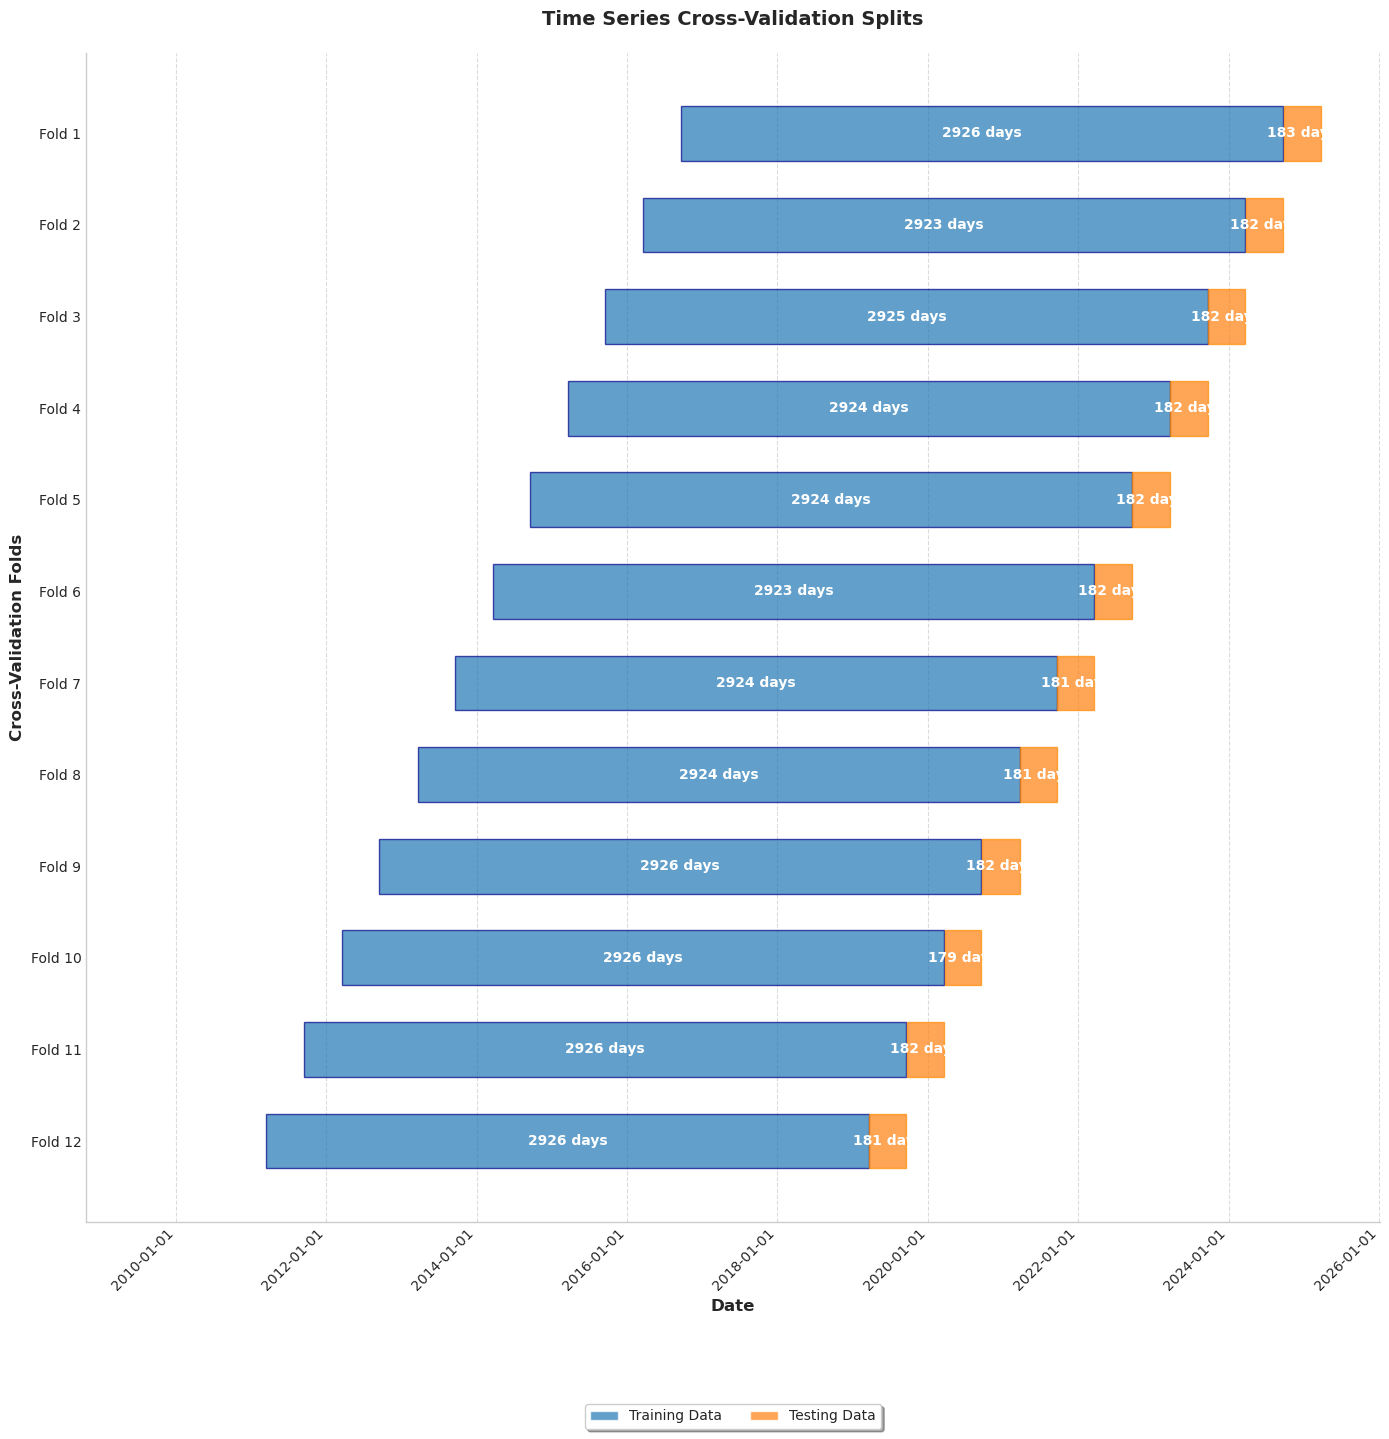

In [21]:
def plot_time_series_cv(cv, X, date_idx='date', title='Time Series Cross-Validation Splits'):
    """
    Creates an enhanced visualization of training and testing periods for time series cross-validation.
    
    Parameters
    ----------
    cv : cross-validator instance
        The time series cross-validator
    X : pandas DataFrame
        Feature matrix with MultiIndex containing a datetime level
    date_idx : str
        The name of the datetime level in the MultiIndex
    title : str
        Title for the plot
    """
    # Set the style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with appropriate height based on number of folds
    fig, ax = plt.subplots(figsize=(14, max(4, 1.2 * cv.n_splits)))
    
    # Get unique dates and convert to datetime if needed
    unique_dates = X.index.get_level_values(date_idx).unique().sort_values()
    if not isinstance(unique_dates[0], pd.Timestamp):
        unique_dates = pd.to_datetime(unique_dates)
    
    # Define visually pleasing colors
    train_color = '#1f77b4'  # Blue
    test_color = '#ff7f0e'   # Orange
    
    # Track min and max dates for x-axis limits
    min_date = unique_dates.min()
    max_date = unique_dates.max()
    
    # Create a legend handler
    legend_elements = [
        Rectangle((0, 0), 1, 1, facecolor=train_color, alpha=0.7, label='Training Data'),
        Rectangle((0, 0), 1, 1, facecolor=test_color, alpha=0.7, label='Testing Data'),
    ]
    
    # Plot each fold
    for i, (train_idx, test_idx) in enumerate(cv.split(X)):
        # Get dates for train and test sets
        train_dates = X.iloc[train_idx].index.get_level_values(date_idx).unique()
        test_dates = X.iloc[test_idx].index.get_level_values(date_idx).unique()
        
        # Calculate y position for this fold
        y_pos = cv.n_splits - i
        
        # Plot training period as a bar with rounded corners
        ax.barh(y_pos, width=(train_dates.max() - train_dates.min()).total_seconds() / (24 * 3600),
                left=train_dates.min(), height=0.6, color=train_color, alpha=0.7, 
                align='center', edgecolor='darkblue', linewidth=1)
        
        # Plot testing period as a bar with rounded corners
        ax.barh(y_pos, width=(test_dates.max() - test_dates.min()).total_seconds() / (24 * 3600),
                left=test_dates.min(), height=0.6, color=test_color, alpha=0.7, 
                align='center', edgecolor='darkorange', linewidth=1)
    
    # Set y-axis labels and ticks
    ax.set_yticks(range(cv.n_splits, 0, -1))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(cv.n_splits)])
    
    # Format x-axis with dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')
    
    # Set limits to add some padding
    date_range = max_date - min_date
    padding = date_range * 0.05  # 5% padding on each side
    ax.set_xlim(min_date - padding, max_date + padding)
    
    # Add labels and title with better styling
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cross-Validation Folds', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Add legend in a good position
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=2, frameon=True, fancybox=True, shadow=True)
    
    # Add a light grid for better readability
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)
    ax.grid(False, axis='y')
    
    # Add annotations showing the fold size
    for i, (train_idx, test_idx) in enumerate(cv.split(X)):
        y_pos = cv.n_splits - i
        train_dates = X.iloc[train_idx].index.get_level_values(date_idx).unique()
        test_dates = X.iloc[test_idx].index.get_level_values(date_idx).unique()
        
        # Annotate train duration
        train_duration = (train_dates.max() - train_dates.min()).days
        ax.text(train_dates.min() + (train_dates.max() - train_dates.min())/2, 
                y_pos, f"{train_duration} days", 
                ha='center', va='center', color='white', fontweight='bold')
        
        # Annotate test duration
        test_duration = (test_dates.max() - test_dates.min()).days
        ax.text(test_dates.min() + (test_dates.max() - test_dates.min())/2, 
                y_pos, f"{test_duration} days", 
                ha='center', va='center', color='white', fontweight='bold')
    
    # Remove spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# Example usage
plot_time_series_cv(cv, X_cv)



### Define CV Parameters

In [22]:
#dense_layer_opts = [(16, 8), (32, 16), (32, 32), (64, 32)]
dense_layer_opts = [(16, 8)]
#dense_layer_opts = [(2,2)]
#activation_opts = ['tanh']
activation_opts = ['relu']
#dropout_opts = [0, .1, .2]
dropout_opts = [0]

In [23]:
param_grid = list(product(dense_layer_opts, activation_opts, dropout_opts))
np.random.shuffle(param_grid)

In [24]:
len(param_grid)

1

To trigger the parameter search, we instantiate a GridSearchCV object, define the fit_params that will be passed to the Keras model’s fit method, and provide the training data to the GridSearchCV fit method:

In [25]:
def get_train_valid_data(X, y, train_idx, test_idx):
    x_train, y_train = X.iloc[train_idx, :], y.iloc[train_idx]
    x_val, y_val = X.iloc[test_idx, :], y.iloc[test_idx]
    return x_train, y_train, x_val, y_val



In [26]:

class MLP(nn.Module):
    def __init__(self, input_dim, dense_layers, activation, dropout):
        """Creates a multi-layer perceptron model
        
        Args:
            input_dim: Number of input features
            dense_layers: List/tuple of layer sizes; one number per layer
            activation: Activation function to use ('relu', 'tanh', etc.)
            dropout: Dropout rate before the final layer
        """
        super(MLP, self).__init__()
        
        # Map string activation to PyTorch function
        if activation == 'relu':
            activation_fn = nn.ReLU()
        elif activation == 'tanh':
            activation_fn = nn.Tanh()
        elif activation == 'sigmoid':
            activation_fn = nn.Sigmoid()
        else:
            activation_fn = nn.ReLU()  # Default
        
        # Build the layers
        layers = []
        prev_size = input_dim
        
        for i, layer_size in enumerate(dense_layers):
            layers.append(nn.Linear(prev_size, layer_size))
            layers.append(activation_fn)
            prev_size = layer_size
        
        # Add dropout before the final layer
        layers.append(nn.Dropout(dropout))
        
        # Add final output layer (for regression, no activation)
        layers.append(nn.Linear(prev_size, 1))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)




In [27]:
def train_model(X_cv, y_cv, cv, param_grid, checkpoint_path, results_path):
    # For reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Define your parameters
    checkpoint_path = Path("checkpoints")
    results_path = Path("results")
    if not results_path.exists():
        results_path.mkdir(parents=True)

    param_grid = list(product(dense_layer_opts, activation_opts, dropout_opts))
    np.random.shuffle(param_grid)

    ic = []
    scaler = StandardScaler()

    for params in param_grid:
        dense_layers, activation, dropout = params
        #for batch_size in [64, 256]:
        for batch_size in [256]:
            print(f"Parameters: {dense_layers}, {activation}, {dropout}, {batch_size}")
            # Create checkpoint directory
            checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(dropout) / str(batch_size)
            if not checkpoint_dir.exists():
                checkpoint_dir.mkdir(parents=True, exist_ok=True)
            
            start = time()
            for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
                # print out to check the dates being tested
                train_dates = X_cv.index.get_level_values('date')[train_idx]
                test_dates = X_cv.index.get_level_values('date')[test_idx]

                print(f"Fold {fold + 1}")
                print(f"  Train period: {train_dates.min().date()} to {train_dates.max().date()}")
                print(f"  Test  period: {test_dates.min().date()} to {test_dates.max().date()}")
                print("-" * 40)

                # get train & validation data
                x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
                
                # Scale features - fit on training data only
                x_train = scaler.fit_transform(x_train)
                x_val = scaler.transform(x_val) # Transform validation data with same scaler
                
                # Set up dataframes to log results
                preds = y_val.to_frame('actual')
                r = pd.DataFrame(index=y_val.groupby(level='date').size().index)
                
                # Create model based on validation parameters
                model, criterion, optimizer = make_model(
                    dense_layers, 
                    activation, 
                    dropout, 
                    input_dim=x_train.shape[1]
                )
                
                # Cross-validate for specified number of epochs
                EPOCHS=10
                for epoch in range(EPOCHS):
                    # Train one epoch
                    loss = train_epoch(
                        model, 
                        criterion, 
                        optimizer, 
                        x_train, 
                        y_train, 
                        batch_size=batch_size, 
                        shuffle=True
                    )
                    
                    # save the state of the model 
                    checkpoint = {'epoch': epoch,
                                  'model_state_dict': model.state_dict(),
                                  'optimizer_state_dict': optimizer.state_dict(),
                                  'loss': loss,
                                  'fold': fold,
                                  'batch_size': batch_size,
                                  'dense_layers':dense_layers,
                                  'activation':activation,
                                  'dropout': dropout}
                    # Save model weights
                    torch.save(
                        #model.state_dict(), 
                        checkpoint,
                        checkpoint_dir / f'ckpt_{fold}_{epoch}.pt'
                    )
                    
                    # Make predictions
                    preds[epoch] = predict(model, x_val)
                    
                    # Calculate metrics (Spearman correlation)
                    r[epoch] = preds.groupby(level='date').apply(
                        lambda x: spearmanr(x.actual, x[epoch])[0]
                    ).to_frame(epoch)
                    
                    elapsed = time() - start
                    print(f"{format_time(elapsed)} | Fold {fold + 1:02d} | Epoch {epoch + 1:02d} | " 
                          f"Mean IC: {r[epoch].mean():7.4f} | Median IC: {r[epoch].median():7.4f}")
                    #print(format_time(time()-start), 
                    #        f'{fold + 1:02d} | {epoch + 1:02d} | {r[epoch].mean():7.4f} | {r[epoch].median():7.4f}')
                
                # Append results for this fold
                ic.append(r.assign(
                    dense_layers=str(dense_layers), 
                    activation=activation, 
                    dropout=dropout,
                    batch_size=batch_size,
                    fold=fold
                ))
            
            #t = time()-start
            pd.concat(ic).to_hdf(results_path / 'scores.h5', 'ic_by_day')
    return ic

In [28]:
do_training = True
if do_training:
    train_model(X_cv, y_cv, cv, param_grid, checkpoint_path, results_path)

Parameters: (16, 8), relu, 0, 256
Fold 1
  Train period: 2016-09-19 to 2024-09-23
  Test  period: 2024-09-24 to 2025-03-26
----------------------------------------
00:00:06 | Fold 01 | Epoch 01 | Mean IC:  0.0008 | Median IC:  0.0052
00:00:11 | Fold 01 | Epoch 02 | Mean IC:  0.0043 | Median IC:  0.0042
00:00:16 | Fold 01 | Epoch 03 | Mean IC:  0.0152 | Median IC:  0.0105
00:00:21 | Fold 01 | Epoch 04 | Mean IC:  0.0191 | Median IC:  0.0237
00:00:26 | Fold 01 | Epoch 05 | Mean IC:  0.0168 | Median IC:  0.0171
00:00:31 | Fold 01 | Epoch 06 | Mean IC:  0.0326 | Median IC:  0.0405
00:00:35 | Fold 01 | Epoch 07 | Mean IC:  0.0240 | Median IC:  0.0264
00:00:40 | Fold 01 | Epoch 08 | Mean IC:  0.0168 | Median IC:  0.0059
00:00:44 | Fold 01 | Epoch 09 | Mean IC:  0.0131 | Median IC: -0.0014
00:00:49 | Fold 01 | Epoch 10 | Mean IC:  0.0282 | Median IC:  0.0248
Fold 2
  Train period: 2016-03-21 to 2024-03-22
  Test  period: 2024-03-25 to 2024-09-23
----------------------------------------
00:00:

### Evaluate predictive performance

In [29]:
params = ['dense_layers', 'dropout', 'batch_size']

In [30]:
ic = pd.read_hdf(results_path / 'scores.h5', 'ic_by_day').drop('activation', axis=1)
ic.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1512 entries, 2024-09-24 to 2019-09-19
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   0             1512 non-null   float64
 1   1             1512 non-null   float64
 2   2             1512 non-null   float64
 3   3             1512 non-null   float64
 4   4             1512 non-null   float64
 5   5             1512 non-null   float64
 6   6             1512 non-null   float64
 7   7             1512 non-null   float64
 8   8             1512 non-null   float64
 9   9             1512 non-null   float64
 10  dense_layers  1512 non-null   object 
 11  dropout       1512 non-null   int64  
 12  batch_size    1512 non-null   int64  
 13  fold          1512 non-null   int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 177.2+ KB


In [31]:
ic.groupby(params).size()

dense_layers  dropout  batch_size
(16, 8)       0        256           1512
dtype: int64

In [32]:
ic_long = pd.melt(ic, id_vars=params + ['fold'], var_name='epoch', value_name='ic')
ic_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   dense_layers  15120 non-null  object 
 1   dropout       15120 non-null  int64  
 2   batch_size    15120 non-null  int64  
 3   fold          15120 non-null  int64  
 4   epoch         15120 non-null  object 
 5   ic            15120 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 708.9+ KB


In [33]:
ic_long

,dense_layers,dropout,batch_size,fold,epoch,ic
0,"(16, 8)",0,256,0,0,-0.001256
1,"(16, 8)",0,256,0,0,-0.212561
2,"(16, 8)",0,256,0,0,0.015946
3,"(16, 8)",0,256,0,0,0.013864
4,"(16, 8)",0,256,0,0,0.063025
...,...,...,...,...,...,...
15115,"(16, 8)",0,256,11,9,0.107319
15116,"(16, 8)",0,256,11,9,0.419812
15117,"(16, 8)",0,256,11,9,-0.064753
15118,"(16, 8)",0,256,11,9,0.221337


In [34]:
ic_long = ic_long.groupby(params+ ['epoch', 'fold']).ic.mean().to_frame('ic').reset_index()

In [35]:
ic_long

,dense_layers,dropout,batch_size,epoch,fold,ic
0,"(16, 8)",0,256,0,0,0.000813
1,"(16, 8)",0,256,0,1,-0.012314
2,"(16, 8)",0,256,0,2,-0.000609
3,"(16, 8)",0,256,0,3,-0.006365
4,"(16, 8)",0,256,0,4,-0.010013
...,...,...,...,...,...,...
115,"(16, 8)",0,256,9,7,0.019882
116,"(16, 8)",0,256,9,8,0.040837
117,"(16, 8)",0,256,9,9,-0.004936
118,"(16, 8)",0,256,9,10,0.001619


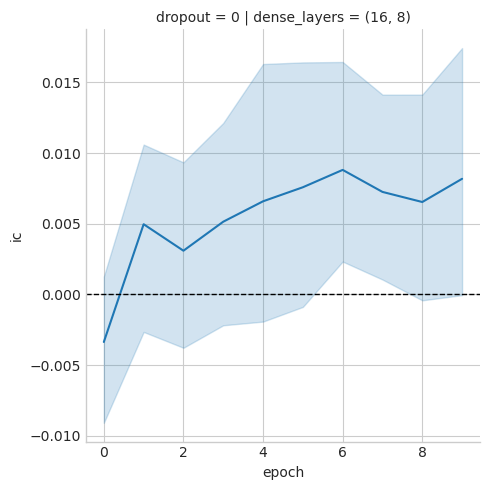

In [36]:
#g = sns.relplot(x='epoch', y='ic', col='dense_layers', row='dropout', 
#                data=ic_long[ic_long.dropout>0], kind='line')
g = sns.relplot(x='epoch', y='ic', col='dense_layers', row='dropout', 
                data=ic_long[ic_long.dropout>-1], kind='line')
g.map(plt.axhline, y=0, ls='--', c='k', lw=1)
g.savefig(results_path / 'ic_lineplot', dpi=300)

In [37]:
# def run_ols(ic):
#     ic.dense_layers = ic.dense_layers.str.replace(', ', '-').str.replace('(', '').str.replace(')', '')
#     data = pd.melt(ic, id_vars=params, var_name='epoch', value_name='ic')
#     data.epoch = data.epoch.astype(int).astype(str).apply(lambda x: f'{int(x):02.0f}')
#     model_data = pd.get_dummies(data.sort_values(params + ['epoch']), columns=['epoch'] + params, drop_first=True).sort_index(1)
#     model_data.columns = [s.split('_')[-1] for s in model_data.columns]
#     model = sm.OLS(endog=model_data.ic, exog=sm.add_constant(model_data.drop('ic', axis=1)))
#     return model.fit()

In [38]:
def run_ols(ic):
    ic.dense_layers = ic.dense_layers.str.replace(', ', '-').str.replace('(', '').str.replace(')', '')
    data = pd.melt(ic, id_vars=params, var_name='epoch', value_name='ic')
    data.epoch = data.epoch.astype(int).astype(str).apply(lambda x: f'{int(x):02.0f}')
    model_data = pd.get_dummies(data.sort_values(params + ['epoch']), columns=['epoch'] + params, drop_first=True, dtype = int).sort_index(axis=1)
    model_data.columns = [s.split('_')[-1] for s in model_data.columns]
    model_data = model_data.dropna() # there can be results from the fits with NaNs
    model = sm.OLS(endog=model_data.ic, exog=sm.add_constant(model_data.drop('ic', axis=1)))
    return model.fit()

In [39]:
# find the best model
model = run_ols(ic.drop('fold', axis=1))

In [40]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     ic   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9854
Date:                Sun, 04 May 2025   Prob (F-statistic):              0.450
Time:                        13:12:03   Log-Likelihood:                 8436.6
No. Observations:               15120   AIC:                        -1.685e+04
Df Residuals:                   15110   BIC:                        -1.678e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0034      0.004     -0.943      0.3

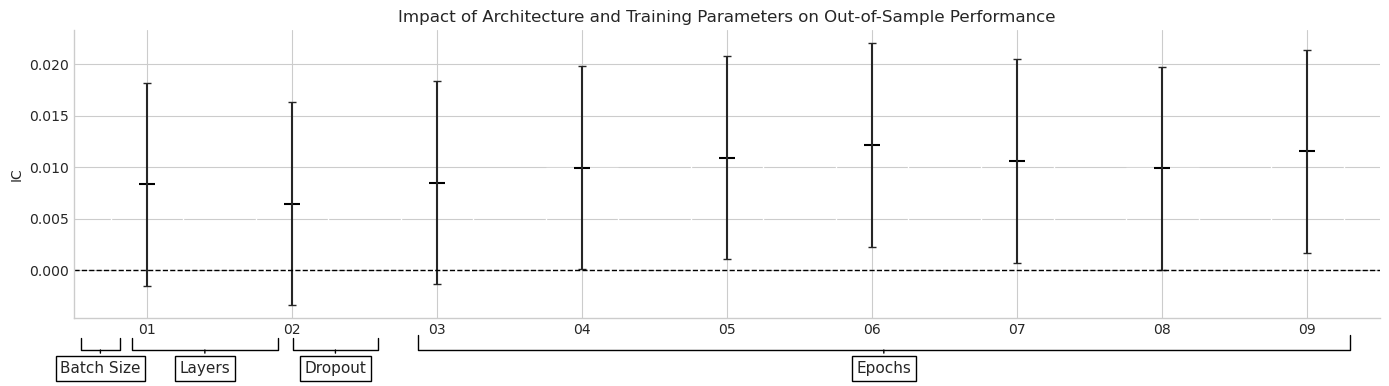

In [41]:
fig, ax = plt.subplots(figsize=(14, 4))

ci = model.conf_int()
errors = ci[1].sub(ci[0]).div(2)

coefs = (model.params.to_frame('coef').assign(error=errors)
         .reset_index().rename(columns={'index': 'variable'}))
coefs = coefs[~coefs['variable'].str.startswith('date') & (coefs.variable != 'const')]

coefs.plot(x='variable', y='coef', kind='bar',
           ax=ax, color='none', capsize=3,
           yerr='error', legend=False, rot=0, title='Impact of Architecture and Training Parameters on Out-of-Sample Performance')
ax.set_ylabel('IC')
ax.set_xlabel('')
#ax.scatter(x=pd.np.arange(len(coefs)), marker='_', s=120, y=coefs['coef'], color='black')
ax.scatter(x=np.arange(len(coefs)), marker='_', s=120, y=coefs['coef'], color='black')
ax.axhline(y=0, linestyle='--', color='black', linewidth=1)
ax.xaxis.set_ticks_position('none')

ax.annotate('Batch Size', xy=(.02, -0.1), xytext=(.02, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=1.3, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Layers', xy=(.1, -0.1), xytext=(.1, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=4.8, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Dropout', xy=(.2, -0.1), xytext=(.2, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=2.8, lengthB=0.8', lw=1.0, color='black'))

ax.annotate('Epochs', xy=(.62, -0.1), xytext=(.62, -0.2),
            xycoords='axes fraction',
            textcoords='axes fraction',
            fontsize=11, ha='center', va='bottom',
            bbox=dict(boxstyle='square', fc='white', ec='black'),
            arrowprops=dict(arrowstyle='-[, widthB=30.5, lengthB=1.0', lw=1.0, color='black'))

sns.despine()
fig.tight_layout()
fig.savefig(results_path / 'ols_coef', dpi=300)

## Make Predictions

In [42]:
def get_best_params(results_path=results_path, n=5):
    """Get the best parameters across all folds by daily median IC"""
    params = ['dense_layers', 'activation', 'dropout', 'batch_size']

    # Load IC scores
    ic = pd.read_hdf(results_path / 'scores.h5', 'ic_by_day')
    
    # Remove fold column if it exists
    if 'fold' in ic.columns:
        ic = ic.drop('fold', axis=1)

    # Define training period
    dates = sorted(ic.index.unique())
    train_period = 24 * 21
    #train_period = 12 * 21

    # Use only training dates for parameter selection
    train_dates = dates[:train_period]
    train_period
    ic = ic.loc[train_dates]
    
    # Group by parameters and find best combinations
    return (ic.groupby(params)
            .median()
            .stack()
            .to_frame('ic')
            .reset_index()
            .rename(columns={'level_4': 'epoch'})
            .nlargest(n=n, columns='ic')
            .drop('ic', axis=1)
            .to_dict('records'))

In [43]:
# def generate_predictions(dense_layers, activation, dropout, batch_size, epoch):
#     data = pd.read_hdf('/home/sabateri/code/courses/machine-learning-for-trading/12_gradient_boosting_machines/data.h5', 'model_data').dropna().sort_index()
#     outcomes = data.filter(like='fwd').columns.tolist()
#     X_cv = data.loc[idx[:, :'2017'], :].drop(outcomes, axis=1)
#     input_dim = X_cv.shape[1]
#     y_cv = data.loc[idx[:, :'2017'], 'r01_fwd']

#     scaler = StandardScaler()
#     predictions = []
    
#     do = '0' if str(dropout) == '0.0' else str(dropout)
#     checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(do) / str(batch_size)
        
#     for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
#         x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
#         x_val = scaler.fit(x_train).transform(x_val)
#         model = make_model(make_tuple(dense_layers), activation, dropout)
#         status = model.load_weights((checkpoint_dir / f'ckpt_{fold}_{epoch}').as_posix())
#         status.expect_partial()
#         predictions.append(pd.Series(model.predict(x_val).squeeze(), index=y_val.index))
#     return pd.concat(predictions)        

In [44]:
def make_tuple(s):
    """Convert string representation of tuple to actual tuple"""
    if isinstance(s, tuple):
        return s
    # Remove parentheses and split by dash or comma
    if '-' in s:
        return tuple(int(x) for x in s.replace('(', '').replace(')', '').split('-'))
    else:
        return tuple(int(x) for x in s.replace('(', '').replace(')', '').split(','))

In [45]:
def generate_predictions(dense_layers, activation, dropout, batch_size, epoch, checkpoint_path):
    checkpoint_path = Path("checkpoints")
    data = pd.read_hdf(DATA_FILE, 'model_data').dropna().sort_index()
    outcomes = data.filter(like='fwd').columns.tolist()
    X_cv = data.loc[idx[:, :END_DATE], :].drop(outcomes, axis=1)
    input_dim = X_cv.shape[1]
    y_cv = data.loc[idx[:, :END_DATE], 'r01_fwd']

    scaler = StandardScaler()
    predictions = []
    
    do = '0' if str(dropout) == '0.0' else str(dropout)
    checkpoint_dir = checkpoint_path / str(dense_layers) / activation / str(do) / str(batch_size)
        
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_cv)):
        # print out to check the dates being tested
        #train_dates = X_cv.index.get_level_values('date')[train_idx]
        test_dates = X_cv.index.get_level_values('date')[test_idx]

        print(f"Fold {fold + 1}")
        #print(f"  Train period: {train_dates.min().date()} to {train_dates.max().date()}")
        print(f"  Test  period: {test_dates.min().date()} to {test_dates.max().date()}")
        print("-" * 40)
        
        x_train, y_train, x_val, y_val = get_train_valid_data(X_cv, y_cv, train_idx, test_idx)
        x_val = scaler.fit(x_train).transform(x_val)
        
        #print(y_val)
        # Create the PyTorch model
        model, _, _ = make_model(
            make_tuple(dense_layers) if isinstance(dense_layers, str) else dense_layers, 
            activation, 
            dropout, 
            input_dim=x_train.shape[1]
        )
        
        # Load the saved PyTorch weights
        checkpoint_path = checkpoint_dir / f'ckpt_{fold}_{epoch}.pt'
        #model.load_state_dict(torch.load(checkpoint_path))
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        
        # Set model to evaluation mode
        model.eval()
        
        # Make predictions
        with torch.no_grad():
            x_tensor = torch.FloatTensor(x_val)
            preds = model(x_tensor).numpy().squeeze()
            
        predictions.append(pd.Series(preds, index=y_val.index))
        
    return pd.concat(predictions)

In [46]:
from datetime import date
results_path = Path("results")

# Get best parameters from the parameters that we trained with
best_params = get_best_params()

# Once we identify the best parameters
# Train one final model using these best hyperparameters on the full training period
predictions = []
checkpoint_path = Path("checkpoints")
for i, params in enumerate(best_params):
    pred = generate_predictions(**params, checkpoint_path=checkpoint_path)
    predictions.append(pred.to_frame(i))

# Combine predictions
predictions = pd.concat(predictions, axis=1)
print(predictions.info())
today_str = date.today().strftime('%Y-%m-%d')
predictions.to_hdf(results_path / f'test_preds_{today_str}.h5', 'predictions')

Fold 1
  Test  period: 2024-09-24 to 2025-03-26
----------------------------------------
Fold 2
  Test  period: 2024-03-25 to 2024-09-23
----------------------------------------
Fold 3
  Test  period: 2023-09-22 to 2024-03-22
----------------------------------------
Fold 4
  Test  period: 2023-03-23 to 2023-09-21
----------------------------------------
Fold 5
  Test  period: 2022-09-21 to 2023-03-22
----------------------------------------
Fold 6
  Test  period: 2022-03-22 to 2022-09-20
----------------------------------------
Fold 7
  Test  period: 2021-09-21 to 2022-03-21
----------------------------------------
Fold 8
  Test  period: 2021-03-23 to 2021-09-20
----------------------------------------
Fold 9
  Test  period: 2020-09-21 to 2021-03-22
----------------------------------------
Fold 10
  Test  period: 2020-03-23 to 2020-09-18
----------------------------------------
Fold 11
  Test  period: 2019-09-20 to 2020-03-20
----------------------------------------
Fold 12
  Test  per

In [47]:
predictions.sort_index(level=1)

,,0,1,2,3,4
symbol,date,,,,,
AAL,2019-03-22,0.002550,-0.001900,0.002101,-0.000702,0.001073
AAOI,2019-03-22,0.003388,-0.000569,0.007713,-0.001508,-0.000851
AAON,2019-03-22,-0.002043,-0.006391,0.001333,-0.004922,-0.006678
AAPL,2019-03-22,0.001998,-0.003498,0.005394,-0.002687,-0.002716
ACGL,2019-03-22,0.000986,-0.006049,0.001139,-0.005744,-0.002350
...,...,...,...,...,...,...
ZIONP,2025-03-26,0.001578,-0.000207,-0.001146,0.002523,0.001020
ZLAB,2025-03-26,0.001510,0.002823,0.000880,0.002663,0.002993
ZS,2025-03-26,0.000290,0.003437,0.001550,0.001357,0.003564


In [48]:
best_params

[{'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 9},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 6},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 2},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 5},
 {'dense_layers': '(16, 8)',
  'activation': 'relu',
  'dropout': 0,
  'batch_size': 256,
  'epoch': 8}]

### How to further improve the results

The relatively simple architecture yields some promising results. To further improve performance, you can
- First and foremost, add new features and more data to the model
- Expand the set of architectures to explore, including more or wider layers
- Inspect the training progress and train for more epochs if the validation error continued to improve at 50 epochs

Finally, you can use more sophisticated architectures, including Recurrent Neural Networks (RNN) and Convolutional Neural Networks that are well suited to sequential data, whereas vanilla feedforward NNs are not designed to capture the ordered nature of the features.
